
# 2D Topology Optimization for Steady Heat Transfer (SIMP + Filters + TR/SQP/MMA)

**Purpose:** A complete, teaching-oriented implementation of 2D topology optimization for steady-state heat conduction on a square grid with a Dirichlet cold edge and insulated other edges. We minimize thermal compliance (or average hot-patch temperature) under a volume constraint, pushing the density field toward binary via SIMP and optional Heaviside projection. Three optimizers are included: **Trust-Region (AL)**, **SQP**, and **MMA**. Animations show the topology evolution.

**Modules in this notebook**
- **Module 0** — Setup & Globals
- **Module 1** — PDE Model (steady conduction with SIMP)
- **Module 2** — Problem (objective, constraints, filters/projection)
- **Module 3** — Adjoint Sensitivity
- **Module 4** — Solver 1: Trust-Region (Augmented Lagrangian)
- **Module 5** — Solver 2: SQP (one linear ineq + box)
- **Module 6** — Solver 3: MMA
- **Module 7** — Driver & Continuation
- **Module 8** — Convergence Plots
- **Module 9** — Animations
- **Module 10** — Sanity checks & dendritic reminder


## Modules 0–7 — Setup, PDE, Problem, Sensitivity, and Solvers

In [52]:
# ==============================
# Module 0 — Setup & Globals
# ==============================
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from matplotlib import animation
from dataclasses import dataclass
from typing import Optional, Dict, Tuple
from IPython.display import HTML, display

np.random.seed(0)
plt.rcParams["figure.figsize"] = (6.5, 5)
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["image.origin"] = "lower"

CFG: Dict = dict(
    nx=64, ny=64,               # grid size (# cells)
    Lx=1.0, Ly=1.0,             # domain size
    k_min=1e-3, k_max=1.0,      # conductivity bounds
    p0=1.0, p_max=4.0,          # SIMP penalization continuation
    vol_frac=0.35,              # volume fraction upper bound
    filter_radius=2.0,          # density filter radius (in cells)
    proj_beta0=2.0, beta_max=32.0,
    use_projection=True,
    q_mag=10.0,                 # magnitude of internal heat source on hot patch
    max_iter=1000,               # max design iterations per solver
    sample_frames=20,           # animation frames per solver
    stop_tol=1e-4,              # relative objective change tol
    lin_tol=1e-8,               # PDE CG tolerance
    max_linits=2000,            # PDE CG max iterations
    objective_kind="avg_hot" # "compliance" or "avg_hot"
)
print("CFG:", CFG)

# ==============================
# Module 1 — PDE Model
# ==============================
@dataclass
class HeatPDE2D:
    nx: int
    ny: int
    Lx: float
    Ly: float
    k_min: float
    k_max: float
    lin_tol: float = 1e-8
    max_linits: int = 2000

    def __post_init__(self):
        self.hx = self.Lx / self.nx
        self.hy = self.Ly / self.ny
        self.N  = self.nx * self.ny
        self._idx = np.arange(self.N, dtype=int).reshape(self.ny, self.nx)

    def simp_k(self, x: np.ndarray, p: float) -> np.ndarray:
        return self.k_min + np.power(np.clip(x, 0, 1), p) * (self.k_max - self.k_min)

    @staticmethod
    def _harmonic_mean(a, b, eps=1e-12):
        return 2.0 * a * b / np.maximum(a + b, eps)

    def assemble_matrix(self, kcell: np.ndarray) -> sp.csr_matrix:
        nx, ny, hx, hy = self.nx, self.ny, self.hx, self.hy
        idx = self._idx

        # Face conductivities (harmonic average)
        kx = self._harmonic_mean(kcell[:, :-1], kcell[:, 1:])      # (ny, nx-1)
        ky = self._harmonic_mean(kcell[:-1, :], kcell[1:, :])      # (ny-1, nx)

        data, rows, cols = [], [], []

        def add(i, j, val):
            rows.append(i); cols.append(j); data.append(val)

        for j in range(ny):
            for i in range(nx):
                p = idx[j, i]
                # bottom Dirichlet (T=0 at j=0): enforce directly
                if j == 0:
                    add(p, p, 1.0)
                    continue

                ap = 0.0
                # left face
                if i > 0:
                    w = kx[j, i-1] / (hx*hx)
                    ap += w; add(p, idx[j, i-1], -w)
                # right face
                if i < nx-1:
                    e = kx[j, i] / (hx*hx)
                    ap += e; add(p, idx[j, i+1], -e)
                # bottom interior face (j>0)
                if j > 0:
                    s = ky[j-1, i] / (hy*hy)
                    ap += s; add(p, idx[j-1, i], -s)
                # top face (Neumann -> no outside neighbor)
                if j < ny-1:
                    n = ky[j, i] / (hy*hy)
                    ap += n; add(p, idx[j+1, i], -n)
                add(p, p, ap)

        A = sp.csr_matrix((data, (rows, cols)), shape=(self.N, self.N))
        return A

    def rhs(self, q: np.ndarray) -> np.ndarray:
        b = q.ravel().copy()
        b[:self.nx] = 0.0  # bottom Dirichlet rows
        return b

    def solve(self, x: np.ndarray, p: float, q: np.ndarray) -> np.ndarray:
        kcell = self.simp_k(x, p)
        A = self.assemble_matrix(kcell)
        b = self.rhs(q)
        Tvec, info = spla.cg(A, b, tol=self.lin_tol, maxiter=self.max_linits)
        if info != 0:
            print(f"[WARN] CG info={info}")
        return Tvec.reshape(self.ny, self.nx)

# --- PATCH: more robust linear solve for the PDE (PCG + warm start + fallback) ---

import numpy as np
import scipy.sparse.linalg as spla

# Adjust global defaults if you like:
CFG["lin_tol"] = 1e-6           # relaxed from 1e-8
CFG["max_linits"] = 5000        # increased from 2000
# Optional conditioning improvement:
# CFG["k_min"] = 1e-2            # improves conditioning at the cost of slightly "grayer" designs

def _pcg_with_fallback(A, b, x0=None, tol=1e-6, maxiter=5000):
    """PCG with Jacobi preconditioner and fallback to sparse direct solve."""
    # Jacobi (diagonal) preconditioner
    D = A.diagonal()
    # Avoid zeros on the diagonal
    D = np.where(np.abs(D) < 1e-14, 1e-14, D)
    M = spla.LinearOperator(A.shape, matvec=lambda v: v / D)

    # CG warm start
    Tvec, info = spla.cg(A, b, tol=tol, maxiter=maxiter, M=M, x0=x0)

    if info > 0:
        # Hit max iterations; try a looser solve once before falling back
        Tvec2, info2 = spla.cg(A, b, tol=max(tol*10, 1e-5), maxiter=maxiter, M=M, x0=Tvec)
        if info2 == 0:
            return Tvec2, 0
        # Final fallback: direct sparse solve (more expensive but reliable)
        try:
            Tvec_direct = spla.spsolve(A, b)
            return Tvec_direct, 0
        except Exception:
            return Tvec, info  # give back best effort
    return Tvec, info

# Monkey-patch HeatPDE2D.solve to use PCG+warm start and store the last solution as x0
def _solve_patched(self, x: np.ndarray, p: float, q: np.ndarray) -> np.ndarray:
    kcell = self.simp_k(x, p)
    A = self.assemble_matrix(kcell)
    b = self.rhs(q)

    # Warm start buffer
    if not hasattr(self, "_last_Tvec"):
        self._last_Tvec = np.zeros(self.N)

    Tvec, info = _pcg_with_fallback(A, b, x0=self._last_Tvec, tol=self.lin_tol, maxiter=self.max_linits)
    if info != 0:
        print(f"[WARN] PCG info={info} (after fallback)")

    self._last_Tvec = Tvec.copy()
    return Tvec.reshape(self.ny, self.nx)

# Apply the patch
HeatPDE2D.solve = _solve_patched
print("Patched HeatPDE2D.solve: PCG + Jacobi preconditioner + warm start + fallback enabled.")

# ==============================
# Module 2 — Problem, Filters, Projection
# ==============================
def build_hotmask_and_q(nx:int, ny:int, q_mag:float, Lx=1.0, Ly=1.0) -> Tuple[np.ndarray, np.ndarray]:
    xg = (np.arange(nx) + 0.5) / nx * Lx
    yg = (np.arange(ny) + 0.5) / ny * Ly
    X, Y = np.meshgrid(xg, yg)
    hot_mask = (Y > 0.7*Ly) & (np.abs(X - 0.5*Lx) < 0.15*Lx)
    q = np.zeros((ny, nx))
    q[hot_mask] = q_mag
    return hot_mask, q

def build_density_filter(nx:int, ny:int, r:float) -> Tuple[sp.csr_matrix, np.ndarray]:
    N = nx*ny
    idx = np.arange(N).reshape(ny, nx)
    rows, cols, vals = [], [], []
    rr = int(np.floor(r))
    for j in range(ny):
        for i in range(nx):
            p = idx[j, i]
            for jj in range(max(0, j-rr), min(ny, j+rr+1)):
                for ii in range(max(0, i-rr), min(nx, i+rr+1)):
                    dist = np.sqrt((i-ii)**2 + (j-jj)**2)
                    if dist <= r:
                        w = r - dist
                        rows.append(p); cols.append(idx[jj, ii]); vals.append(w)
    H = sp.csr_matrix((vals, (rows, cols)), shape=(N, N))
    Hs = np.array(H.sum(axis=1)).ravel()
    return H, Hs

def apply_filter(H: sp.csr_matrix, Hs: np.ndarray, x: np.ndarray) -> np.ndarray:
    xf = (H @ x.ravel()) / np.maximum(Hs, 1e-12)
    return xf.reshape(x.shape)

def heaviside_proj(xf: np.ndarray, beta: float, eta: float=0.5) -> np.ndarray:
    num = np.tanh(beta*eta) + np.tanh(beta*(xf - eta))
    den = np.tanh(beta*eta) + np.tanh(beta*(1 - eta))
    return num / np.maximum(den, 1e-12)

def dheaviside_dxf(xf: np.ndarray, beta: float, eta: float=0.5) -> np.ndarray:
    den = np.tanh(beta*eta) + np.tanh(beta*(1 - eta))
    return (beta * (1 - np.tanh(beta*(xf - eta))**2)) / np.maximum(den, 1e-12)

def objective(T: np.ndarray, q: np.ndarray, hot_mask: Optional[np.ndarray], kind: str="compliance") -> float:
    if kind == "compliance":
        return float(np.sum(q * T))
    elif kind == "avg_hot":
        if hot_mask is None or not np.any(hot_mask):
            raise ValueError("avg_hot objective requires a non-empty hot_mask")
        return float(np.mean(T[hot_mask]))
    else:
        raise ValueError(f"Unknown objective kind: {kind}")

@dataclass
class TopOptProblem:
    pde: HeatPDE2D
    H: sp.csr_matrix
    Hs: np.ndarray
    cfg: Dict
    hot_mask: Optional[np.ndarray] = None

    def physical_design(self, x: np.ndarray, beta: Optional[float]):
        xf = apply_filter(self.H, self.Hs, x)
        if self.cfg.get("use_projection", True) and (beta is not None):
            xp = heaviside_proj(xf, beta)
            dproj = dheaviside_dxf(xf, beta)
        else:
            xp = xf
            dproj = np.ones_like(xf)
        return xp, dproj, xf

    def eval(self, x: np.ndarray, p_simp: float, beta: Optional[float], q: np.ndarray, kind: str=None):
        if kind is None: kind = self.cfg["objective_kind"]
        xp, dproj, xf = self.physical_design(x, beta)

        T = self.pde.solve(xp, p_simp, q)
        J = objective(T, q, self.hot_mask, kind=kind)
        g = np.mean(x) - self.cfg["vol_frac"]

        # Adjoint
        if kind == "compliance":
            lam = T
        else:
            rhs = np.zeros_like(T)
            rhs[self.hot_mask] = 1.0 / max(1, np.count_nonzero(self.hot_mask))
            kcell = self.pde.simp_k(xp, p_simp)
            A = self.pde.assemble_matrix(kcell)
            b = self.pde.rhs(rhs)
            lam_vec, info = spla.cg(A, b, tol=self.pde.lin_tol, maxiter=self.pde.max_linits)
            if info != 0: print(f"[WARN] adjoint CG info={info}")
            lam = lam_vec.reshape(self.pde.ny, self.pde.nx)

        # gradients via central diffs
        def grad_central(F):
            Fx = np.zeros_like(F); Fy = np.zeros_like(F)
            Fx[:, 1:-1] = (F[:, 2:] - F[:, :-2]) / (2*self.pde.hx)
            Fy[1:-1, :] = (F[2:, :] - F[:-2, :]) / (2*self.pde.hy)
            Fx[:, 0] = (F[:, 1] - F[:, 0]) / self.pde.hx
            Fx[:, -1] = (F[:, -1] - F[:, -2]) / self.pde.hx
            Fy[0, :] = (F[1, :] - F[0, :]) / self.pde.hy
            Fy[-1, :] = (F[-1, :] - F[-2, :]) / self.pde.hy
            return Fx, Fy

        Tx, Ty = grad_central(T)
        Lx, Ly = grad_central(lam)
        dot_grad = Tx*Lx + Ty*Ly

        p = p_simp
        kfac = (self.pde.k_max - self.pde.k_min)
        dk_dxphys = p * np.power(np.clip(xp, 0, 1), max(p-1.0, 0.0)) * kfac
        dJ_dphys = - dk_dxphys * dot_grad

        dJ_dxf = dJ_dphys * dproj
        dJdx_vec = self.H.T @ (dJ_dxf.ravel() / np.maximum(self.Hs, 1e-12))
        gradJ = dJdx_vec.reshape(x.shape)

        gradg = np.ones_like(x) / x.size
        return J, g, gradJ, gradg, T, xp

# ==============================
# Helpers: projections & history
# ==============================
class History:
    def __init__(self):
        self.J = []; self.g = []; self.mean_x = []; self.max_dx = []; self.p = []; self.beta = []

def project_box_volume(z: np.ndarray, vol_frac: float) -> np.ndarray:
    """Project z onto {x in [0,1]^n : mean(x) = vol_frac} via water-filling bisection."""
    lo, hi = -1.0, 1.0
    def mean_after(tau):
        return float(np.mean(np.clip(z - tau, 0.0, 1.0)))
    # expand bounds until feasible
    while mean_after(lo) < vol_frac: lo *= 2.0
    while mean_after(hi) > vol_frac: hi *= 2.0
    for _ in range(50):
        mid = 0.5*(lo+hi)
        m = mean_after(mid)
        if m > vol_frac: lo = mid
        else: hi = mid
    return np.clip(z - hi, 0.0, 1.0)

def resample_frames(frames, target=20):
    if len(frames) <= target: return frames
    idx = np.linspace(0, len(frames)-1, target).round().astype(int)
    return [frames[i] for i in idx]

# ==============================
# Module 4 — TR Solver (AL + projected step)
# ==============================
# ==============================
# PATCH: Robust Projected Trust-Region (merit line search)
#   - preserves volume via projection
#   - sufficient-decrease Armijo on the AL-merit
#   - diagonal preconditioning + BB-like scaling
#   - fixes frame snapshots (uses current xp)
# ==============================

# ==============================
# TR PATCH: Robust projected trust-region with verbose logging
# ==============================

class TRSolver:
    def __init__(
        self,
        problem: TopOptProblem,
        delta0: float = 0.25,      # initial trust radius (cap on step components)
        move_limit: float = 0.25,  # per-iteration move cap
        verbose: bool = True,
        print_every: int = 1,
        min_iters: int = 10,       # don't stop before this many iterations
        max_backtrack: int = 20,   # Armijo LS budget
        c1: float = 1e-4,          # Armijo parameter
    ):
        self.pb = problem
        self.delta = delta0
        self.move_limit = move_limit
        self.verbose = verbose
        self.print_every = print_every
        self.min_iters = min_iters
        self.max_backtrack = max_backtrack
        self.c1 = c1

        self.mu = 0.0             # AL multiplier (kept for generality)
        self.rho = 10.0            # AL penalty
        self.Hdiag = None          # diagonal preconditioner
        self._rng = np.random.default_rng(0)

    # merit (AL form; g≈0 due to equality projection but keep robust)
    def _merit(self, J: float, g: float) -> float:
        return J + self.mu*max(0.0, g) + 0.5*self.rho*max(0.0, g)**2

    def _dir(self, grad_phi: np.ndarray) -> np.ndarray:
        # preconditioned steepest descent (NO mean projection; projection happens on trial x)
        d = - grad_phi / np.maximum(self.Hdiag, 1e-8)
        # cap by per-component move limit and trust radius
        d = np.clip(d, -self.move_limit, self.move_limit)
        d = np.clip(d, -self.delta, self.delta)
        # symmetry nudge if nearly zero
        if np.max(np.abs(d)) < 1e-12:
            # small, zero-mean random nudge projected back later
            eps = 1e-3
            r = self._rng.standard_normal(size=d.shape)
            r -= np.mean(r)
            d = eps * r
        return d

    def _project(self, x):
        # box + exact volume
        return project_box_volume(np.clip(x, 0.0, 1.0), self.pb.cfg["vol_frac"])

    def _line_search(self, x, d, p, beta, q, J, g, grad_phi):
        phi0 = self._merit(J, g)
        alpha = min(1.0, self.delta)
        tried = 0
        accepted_payload = None

        for tried in range(1, self.max_backtrack + 1):
            x_trial = self._project(x + alpha * d)
            Jt, gt, gradJt, gradgt, Tt, xpt = self.pb.eval(x_trial, p, beta, q, kind=self.pb.cfg["objective_kind"])
            phit = self._merit(Jt, gt)

            # directional derivative estimate using actual projected displacement
            s = (x_trial - x)
            desc = float(grad_phi.ravel() @ s.ravel())

            if phit <= phi0 + self.c1 * desc:
                accepted_payload = (x_trial, Jt, gt, gradJt, gradgt, Tt, xpt, alpha, tried, desc, phit - phi0)
                break
            alpha *= 0.5

        return accepted_payload, tried

    def solve(self, x0: np.ndarray, q: np.ndarray, schedule) -> Dict:
        x = x0.copy()
        hist = History()
        frames = []

        p = schedule["p_init"]; beta = schedule.get("beta_init", None)
        self.Hdiag = np.ones_like(x)

        # initial eval
        J, g, gradJ, gradg, T, xp = self.pb.eval(x, p, beta, q, kind=self.pb.cfg["objective_kind"])
        grad_phi = gradJ + (self.mu + self.rho*max(0.0, g))*gradg
        phi = self._merit(J, g)
        phi_prev = phi

        if self.verbose:
            print(f"[TR] it=0   phi={phi:.6e}  J={J:.6e}  g={g:.2e}  ||grad_phi||inf={np.max(np.abs(grad_phi)):.3e}")

        for it in range(1, schedule["max_iter"] + 1):
            # continuation
            p, beta = schedule["update_continuation"](it, p, beta)

            # direction
            d = self._dir(grad_phi)
            d_inf = float(np.max(np.abs(d)))

            # projected Armijo line search
            accepted, tried = self._line_search(x, d, p, beta, q, J, g, grad_phi)

            if accepted is not None:
                x_new, Jn, gn, gradJn, gradgn, Tn, xpn, alpha, ls_tries, desc, dphi = accepted

                # update diag preconditioner (BB-like from merit gradient)
                grad_phi_new = gradJn + (self.mu + self.rho*max(0.0, gn))*gradgn
                s = x_new - x
                y = grad_phi_new - grad_phi
                self.Hdiag = np.clip(np.abs(y) / (np.abs(s) + 1e-12), 1e-3, 1e3)

                # accept
                x, J, g, grad_phi = x_new, Jn, gn, grad_phi_new
                phi_new = self._merit(J, g)

                # radius update
                if alpha > 0.5 * self.delta:
                    self.delta = min(2.0*self.delta, 0.5)
                else:
                    self.delta = max(0.5*self.delta, 1e-3)

                # AL multiplier (kept for generality)
                if g > 0: self.mu += self.rho * g

                # frame (current physical design)
                if (it==1) or (it==schedule["max_iter"]) or (it % max(1, schedule["max_iter"]//self.pb.cfg["sample_frames"]) == 0):
                    frames.append(xpn.copy())

                # logging
                if self.verbose and (it % self.print_every == 0):
                    print(
                        f"[TR] it={it:<4d} ACCEPT  alpha={alpha:.2e}  ls={ls_tries:<2d}  "
                        f"||d||inf={d_inf:.2e}  delta={self.delta:.2e}  "
                        f"phi={phi_new:.6e}  dphi={phi_new-phi_prev:.2e}  "
                        f"J={J:.6e}  g={g:.2e}  ||grad_phi||inf={np.max(np.abs(grad_phi)):.2e}"
                    )

                # convergence (after min_iters)
                rel = abs(phi_prev - phi_new) / max(1.0, abs(phi_prev))
                phi_prev = phi_new
                if (it >= self.min_iters) and (rel < self.pb.cfg["stop_tol"]) and (d_inf < 1e-3):
                    break
                phi = phi_new

            else:
                # reject (couldn't find decrease) → shrink TR and try again next iter
                self.delta = max(0.25*self.delta, 1e-3)
                if self.verbose and (it % self.print_every == 0):
                    print(
                        f"[TR] it={it:<4d} REJECT ls>={self.max_backtrack:<2d}  "
                        f"||d||inf={d_inf:.2e}  delta-> {self.delta:.2e}  "
                        f"phi={phi:.6e}  J={J:.6e}  g={g:.2e}  ||grad_phi||inf={np.max(np.abs(grad_phi)):.2e}"
                    )
                # small symmetry nudge so next iter can move
                r = self._rng.standard_normal(size=x.shape); r -= np.mean(r)
                x = self._project(x + 1e-4 * r)

                # frame of current phys design
                if (it==1) or (it==schedule["max_iter"]) or (it % max(1, schedule["max_iter"]//self.pb.cfg["sample_frames"]) == 0):
                    xp_now = self.pb.physical_design(x, beta)[0]
                    frames.append(xp_now.copy())

            # history
            hist.J.append(J); hist.g.append(g); hist.mean_x.append(float(np.mean(x)))
            hist.max_dx.append(d_inf); hist.p.append(p); hist.beta.append(beta if beta is not None else 0.0)

        # final state (ensure consistency)
        xp_final = self.pb.physical_design(x, beta)[0]
        T_final = self.pb.pde.solve(xp_final, p, q)
        frames = resample_frames(frames, target=self.pb.cfg["sample_frames"])
        return dict(name="TR", x_final=x, T_final=T_final, hist=hist.__dict__, frames=frames)
        
# ==============================
# Module 5 — SQP Solver (boxed + single linear)
# ==============================
class SQPSolver:
    def __init__(self, problem: TopOptProblem, move_limit: float=0.15):
        self.pb = problem
        self.move_limit = move_limit
        self.Bdiag = None

    def _solve_boxed_qp_one_linear(self, grad: np.ndarray, A: np.ndarray, b: float) -> np.ndarray:
        """Min 0.5 s^T B s + grad^T s s.t. A^T s + b <= 0, and |s_i| <= move_limit."""
        if self.Bdiag is None: self.Bdiag = np.ones_like(grad)
        B = np.maximum(self.Bdiag.ravel(), 1e-4)
        A = A.ravel()

        def s_of(lmb):
            s = -(grad.ravel() + lmb*A) / B
            s = np.clip(s, -self.move_limit, self.move_limit)
            return s

        def phi(lmb):
            return float(A @ s_of(lmb) + b)

        if phi(0.0) <= 0.0:
            return s_of(0.0).reshape(grad.shape)

        l_lo, l_hi = 0.0, 1.0
        while phi(l_hi) > 0.0 and l_hi < 1e6: l_hi *= 2.0
        for _ in range(50):
            mid = 0.5*(l_lo + l_hi)
            if phi(mid) > 0: l_lo = mid
            else: l_hi = mid
        return s_of(l_hi).reshape(grad.shape)

    def solve(self, x0: np.ndarray, q: np.ndarray, schedule) -> Dict:
        x = x0.copy()
        hist = History(); frames = []
        p = schedule["p_init"]; beta = schedule.get("beta_init", None)
        J_prev = None
        self.Bdiag = np.ones_like(x0)

        # initial eval
        J, g, gradJ, gradg, T, xp = self.pb.eval(x, p, beta, q, kind=self.pb.cfg["objective_kind"])
        grad_phi = gradJ + 1e3*max(0.0, g)*gradg  # merit gradient

        for it in range(schedule["max_iter"]):
            p, beta = schedule["update_continuation"](it, p, beta)

            s = self._solve_boxed_qp_one_linear(grad=grad_phi, A=gradg, b=g)
            z = np.clip(x + s, 0.0, 1.0)
            x_trial = project_box_volume(z, self.pb.cfg["vol_frac"])

            Jt, gt, gradJt, gradgt, Tt, xpt = self.pb.eval(x_trial, p, beta, q, kind=self.pb.cfg["objective_kind"])
            phi = J + 1e3*max(0.0, g)
            phit = Jt + 1e3*max(0.0, gt)

            # Armijo on merit (note the sign: we need sufficient decrease)
            descent = float(grad_phi.ravel() @ (x_trial - x).ravel())
            if phit <= phi + 1e-4*descent:  # accept
                x_old = x; grad_phi_old = grad_phi
                x = x_trial; J, g = Jt, gt
                grad_phi = gradJt + 1e3*max(0.0, g)*gradgt
                # diagonal update from gradient difference
                y = grad_phi - grad_phi_old
                svec = (x - x_old)
                self.Bdiag = np.clip(np.abs(y) / (np.abs(svec)+1e-8), 1e-4, 1e4)
            else:
                # backtrack in the projected direction
                alpha = 0.5
                accepted = False
                for _ in range(12):
                    z = np.clip(x + alpha*(x_trial - x), 0.0, 1.0)
                    xt = project_box_volume(z, self.pb.cfg["vol_frac"])
                    Jb, gb, gradJb, gradgb, Tb, xpb = self.pb.eval(xt, p, beta, q, kind=self.pb.cfg["objective_kind"])
                    phib = Jb + 1e3*max(0.0, gb)
                    if phib <= phi + 1e-4*alpha*descent:
                        x_old = x; grad_phi_old = grad_phi
                        x = xt; J, g = Jb, gb
                        grad_phi = gradJb + 1e3*max(0.0, g)*gradgb
                        y = grad_phi - grad_phi_old
                        svec = (x - x_old)
                        self.Bdiag = np.clip(np.abs(y) / (np.abs(svec)+1e-8), 1e-4, 1e4)
                        accepted = True
                        break
                    alpha *= 0.5
                if not accepted:
                    x = project_box_volume(x, self.pb.cfg["vol_frac"])

            hist.J.append(J); hist.g.append(g); hist.mean_x.append(np.mean(x))
            hist.max_dx.append(float(np.max(np.abs(s)))); hist.p.append(p); hist.beta.append(beta if beta is not None else 0.0)
            if (it==0) or (it==schedule["max_iter"]-1) or (it % max(1, schedule["max_iter"]//self.pb.cfg["sample_frames"]) == 0):
                frames.append(xp.copy())
                xp = self.pb.physical_design(x, beta)[0]

            if J_prev is not None:
                rel = np.abs(J - J_prev)/max(1.0, np.abs(J_prev))
                if rel < self.pb.cfg["stop_tol"] and np.max(np.abs(s)) < 1e-3:
                    break
            J_prev = J

        frames = resample_frames(frames, target=self.pb.cfg["sample_frames"])
        return dict(name="SQP", x_final=x, T_final=Tt, hist=hist.__dict__, frames=frames)

# ==============================
# Module 6 — MMA Solver (OC-style update with bisection on lambda)
# ==============================
class MMASolver:
    def __init__(self, problem: TopOptProblem, move_limit: float=0.2):
        self.pb = problem
        self.move_limit = move_limit

    def _oc_update(self, x: np.ndarray, dJdx: np.ndarray, vol_frac: float) -> np.ndarray:
        """Standard OC-like update (TOP88-style), box [0,1], move limits, enforce mean(x)=vol_frac."""
        m = self.move_limit
        l_lo, l_hi = 1e-12, 1e12
        xL = np.maximum(0.0, x - m)
        xU = np.minimum(1.0, x + m)
        eta = 1e-8
        def x_of(lmb):
            ratio = -dJdx / (lmb + eta)
            ratio = np.maximum(ratio, 0.0)
            xnew = x * np.sqrt(ratio)
            return np.clip(xnew, xL, xU)
        # bisection to meet volume constraint
        for _ in range(50):
            l_mid = np.sqrt(l_lo * l_hi)
            xm = x_of(l_mid)
            if np.mean(xm) - vol_frac > 0:
                l_lo = l_mid
            else:
                l_hi = l_mid
        x_new = x_of(l_hi)
        # exact mean projection for robustness
        x_new = project_box_volume(x_new, vol_frac)
        return x_new

    def solve(self, x0: np.ndarray, q: np.ndarray, schedule) -> Dict:
        x = x0.copy()
        hist = History(); frames = []
        p = schedule["p_init"]; beta = schedule.get("beta_init", None)
        J_prev = None

        for it in range(schedule["max_iter"]):
            p, beta = schedule["update_continuation"](it, p, beta)
            J, g, gradJ, gradg, T, xp = self.pb.eval(x, p, beta, q, kind=self.pb.cfg["objective_kind"])
            x_new = self._oc_update(x, gradJ, self.pb.cfg["vol_frac"])

            hist.J.append(J); hist.g.append(g); hist.mean_x.append(np.mean(x))
            hist.max_dx.append(float(np.max(np.abs(x_new - x)))); hist.p.append(p); hist.beta.append(beta if beta is not None else 0.0)
            if (it==0) or (it==schedule["max_iter"]-1) or (it % max(1, schedule["max_iter"]//self.pb.cfg["sample_frames"]) == 0):
                frames.append(xp.copy())

            if J_prev is not None and np.abs(J - J_prev)/max(1.0, np.abs(J_prev)) < self.pb.cfg["stop_tol"] and np.max(np.abs(x_new - x)) < 1e-3:
                x = x_new; break
            x = x_new; J_prev = J

        frames = resample_frames(frames, target=self.pb.cfg["sample_frames"])
        return dict(name="MMA", x_final=x, T_final=T, hist=hist.__dict__, frames=frames)

# ==============================
# Module 7 — Driver & Continuation
# ==============================
def make_schedule(cfg: Dict):
    steps = cfg["max_iter"]
    def update_continuation(it, p, beta):
        if it in {int(steps*0.33), int(steps*0.66)}:
            p = min(cfg["p_max"], p + 1.0)
        if cfg.get("use_projection", True):
            if beta is None and it > steps*0.25:
                beta = cfg["proj_beta0"]
            elif beta is not None and it in {int(steps*0.5), int(steps*0.75)}:
                beta = min(cfg["beta_max"], 2.0*beta)
        return p, beta

    return dict(p_init=cfg["p0"], beta_init=None if not cfg.get("use_projection", True) else None,
                update_continuation=update_continuation, max_iter=cfg["max_iter"])

def run_all_solvers(cfg: Dict):
    nx, ny = cfg["nx"], cfg["ny"]
    pde = HeatPDE2D(nx=nx, ny=ny, Lx=cfg["Lx"], Ly=cfg["Ly"],
                    k_min=cfg["k_min"], k_max=cfg["k_max"],
                    lin_tol=cfg["lin_tol"], max_linits=cfg["max_linits"])
    hot_mask, q = build_hotmask_and_q(nx, ny, cfg["q_mag"], cfg["Lx"], cfg["Ly"])
    H, Hs = build_density_filter(nx, ny, cfg["filter_radius"])
    problem = TopOptProblem(pde=pde, H=H, Hs=Hs, cfg=cfg, hot_mask=hot_mask)
    x0 = np.full((ny, nx), cfg["vol_frac"], dtype=float)
    schedule = make_schedule(cfg)

    tr  = TRSolver(problem)
    sqp = SQPSolver(problem)
    mma = MMASolver(problem)

    res_tr  = tr.solve(x0, q, schedule)
    res_sqp = sqp.solve(x0, q, schedule)
    res_mma = mma.solve(x0, q, schedule)
    return [res_tr, res_sqp, res_mma], dict(problem=problem, q=q, pde=pde)

print("Definitions loaded (Modules 0–7).")


CFG: {'nx': 64, 'ny': 64, 'Lx': 1.0, 'Ly': 1.0, 'k_min': 0.001, 'k_max': 1.0, 'p0': 1.0, 'p_max': 4.0, 'vol_frac': 0.35, 'filter_radius': 2.0, 'proj_beta0': 2.0, 'beta_max': 32.0, 'use_projection': True, 'q_mag': 10.0, 'max_iter': 1000, 'sample_frames': 20, 'stop_tol': 0.0001, 'lin_tol': 1e-08, 'max_linits': 2000, 'objective_kind': 'avg_hot'}
Patched HeatPDE2D.solve: PCG + Jacobi preconditioner + warm start + fallback enabled.
Definitions loaded (Modules 0–7).


## Modules 8–9 — Convergence Plots & Animations

In [45]:
def plot_convergence(results):
    plt.figure()
    for res in results:
        plt.plot(res["hist"]["J"], label=res["name"])
    plt.xlabel("Iteration"); plt.ylabel("Objective")
    plt.grid(True); plt.legend(); plt.title("Convergence (Objective)")
    plt.show()

def plot_convergence_semilogy(results):
    # Common baseline across methods for consistent "gap" visualization
    global_min = min(np.min(res["hist"]["J"]) for res in results)
    plt.figure()
    for res in results:
        y = np.array(res["hist"]["J"]) - global_min + 1e-12
        plt.semilogy(y, label=res["name"])
    plt.xlabel("Iteration"); plt.ylabel("J - global_min(J)")
    plt.grid(True, which="both"); plt.legend(); plt.title("Convergence (Semilogy, common baseline)")
    plt.show()

# --- Animation: JS (no ffmpeg) fallback by default ---

from IPython.display import HTML, display
import matplotlib.pyplot as plt
from matplotlib import animation

def make_animation(frames, title="Evolution", interval_ms=300, prefer="auto"):
    """
    prefer: "auto" | "js" | "video"
      - "auto": try HTML5 video if ffmpeg is available, else JS
      - "js": always use JS (no ffmpeg needed)
      - "video": try video; if not available, silently falls back to JS
    """
    fig, ax = plt.subplots()
    im = ax.imshow(frames[0], cmap="gray", vmin=0, vmax=1, animated=True)
    ax.set_title(f"{title} (frame 1/{len(frames)})")
    ax.set_xticks([]); ax.set_yticks([])

    def init():
        im.set_array(frames[0]); 
        return (im,)

    def update(k):
        im.set_array(frames[k])
        ax.set_title(f"{title} (frame {k+1}/{len(frames)})")
        return (im,)

    anim = animation.FuncAnimation(
        fig, update, init_func=init, frames=len(frames),
        interval=interval_ms, blit=True
    )
    plt.close(fig)

    # Decide renderer
    if prefer == "js":
        return HTML(anim.to_jshtml())
    if prefer == "video":
        try:
            return HTML(anim.to_html5_video())
        except Exception:
            return HTML(anim.to_jshtml())
    # auto
    try:
        from matplotlib.animation import writers
        if writers.is_available("ffmpeg"):
            return HTML(anim.to_html5_video())
    except Exception:
        pass
    return HTML(anim.to_jshtml())

def resample_frames(frames, target=20):
    if len(frames) <= target:
        return frames
    import numpy as np
    idx = np.linspace(0, len(frames)-1, target).round().astype(int)
    return [frames[i] for i in idx]

def show_all_animations(results, target_frames=20, prefer="js"):
    """
    prefer: pass "js" to guarantee no-ffmpeg path in any env.
    """
    for res in results:
        frames = resample_frames(res["frames"], target=target_frames)
        display(make_animation(frames, title=f"{res['name']} Topology", prefer=prefer))
    return None

print("Plotting helpers loaded (Modules 8–9).")


Plotting helpers loaded (Modules 8–9).



## Module 10 — Sanity Checks & Dendritic Reminder

- **Boundary conditions:** Dirichlet cold sink \(T=0\) on bottom edge; other edges insulated.
- **Source:** Localized hot patch near the top (narrow band horizontally) to encourage dendritic branches.
- **Objective:** Default to **thermal compliance** \(J=\int qT\) (or average hot-patch \(T\)) under \(\text{vol\_frac}\in[0.2,0.4]\).
- **Binary push:** SIMP \(p\) continuation and (optional) Heaviside projection \(\beta\) continuation.
- **Anti-checkerboard:** Density filter radius \(r\) (increase if needed).
- **Tips:** If solution remains gray → increase \(p,\beta\) later; if noisy → larger filter radius; if pathways look grid-biased → harmonic face averaging helps.



### Quick Start

You can cut iterations to test quickly by decreasing `CFG["max_iter"]` or the grid size.

```python
results, ctx = run_all_solvers(CFG)
plot_convergence(results)
plot_convergence_semilogy(results)
_ = show_all_animations(results)  # displays three animations inline
```


In [53]:
# Build the PDE problem and the design operators
pde = HeatPDE2D(nx=CFG["nx"], ny=CFG["ny"], Lx=CFG["Lx"], Ly=CFG["Ly"],
                k_min=CFG["k_min"], k_max=CFG["k_max"],
                lin_tol=CFG["lin_tol"], max_linits=CFG["max_linits"])
hot_mask, q = build_hotmask_and_q(CFG["nx"], CFG["ny"], CFG["q_mag"], CFG["Lx"], CFG["Ly"])
H, Hs = build_density_filter(CFG["nx"], CFG["ny"], CFG["filter_radius"])
problem = TopOptProblem(pde=pde, H=H, Hs=Hs, cfg=CFG, hot_mask=hot_mask)

# Create the continuation schedule
schedule = make_schedule(CFG)

# re-create the schedule and problem if needed, then:
tr = TRSolver(problem, delta0=0.25, move_limit=0.25, verbose=True, print_every=1, min_iters=10)
schedule = make_schedule(CFG)
res_tr = tr.solve(np.full((CFG["ny"], CFG["nx"]), CFG["vol_frac"]), q, schedule)

# if symmetry still stalls early, try a tiny initial perturbation:
# x0 = np.clip(CFG["vol_frac"] + 0.01*np.random.randn(CFG["ny"], CFG["nx"]), 0, 1)
# res_tr = tr.solve(x0, q, schedule)

/var/folders/6n/_qkrlft93jn2pxhjxv34r4fw0000gn/T/ipykernel_56101/2673692933.py:141: DeprecationWarning: 'scipy.sparse.linalg.cg' keyword argument `tol` is deprecated in favor of `rtol` and will be removed in SciPy v1.14.0. Until then, if set, it will override `rtol`.
  Tvec, info = spla.cg(A, b, tol=tol, maxiter=maxiter, M=M, x0=x0)
/var/folders/6n/_qkrlft93jn2pxhjxv34r4fw0000gn/T/ipykernel_56101/2673692933.py:265: DeprecationWarning: 'scipy.sparse.linalg.cg' keyword argument `tol` is deprecated in favor of `rtol` and will be removed in SciPy v1.14.0. Until then, if set, it will override `rtol`.
  lam_vec, info = spla.cg(A, b, tol=self.pde.lin_tol, maxiter=self.pde.max_linits)


[TR] it=0   phi=2.365341e+00  J=2.365341e+00  g=-5.55e-17  ||grad_phi||inf=4.104e-03
[TR] it=1    ACCEPT  alpha=2.50e-01  ls=1   ||d||inf=4.10e-03  delta=5.00e-01  phi=2.364867e+00  dphi=-4.75e-04  J=2.364867e+00  g=-5.55e-16  ||grad_phi||inf=4.09e-03
[TR] it=2    ACCEPT  alpha=5.00e-01  ls=1   ||d||inf=2.50e-01  delta=5.00e-01  phi=2.359754e+00  dphi=-5.11e-03  J=2.359754e+00  g=-5.00e-16  ||grad_phi||inf=3.68e-03
[TR] it=3    ACCEPT  alpha=5.00e-01  ls=1   ||d||inf=2.50e-01  delta=5.00e-01  phi=2.321458e+00  dphi=-3.83e-02  J=2.321458e+00  g=-6.66e-16  ||grad_phi||inf=3.59e-03
[TR] it=4    ACCEPT  alpha=5.00e-01  ls=1   ||d||inf=2.50e-01  delta=5.00e-01  phi=2.310151e+00  dphi=-1.13e-02  J=2.310151e+00  g=-1.67e-16  ||grad_phi||inf=3.40e-03
[TR] it=5    ACCEPT  alpha=5.00e-01  ls=1   ||d||inf=2.50e-01  delta=5.00e-01  phi=2.277246e+00  dphi=-3.29e-02  J=2.277246e+00  g=-4.44e-16  ||grad_phi||inf=3.25e-03
[TR] it=6    ACCEPT  alpha=5.00e-01  ls=1   ||d||inf=2.50e-01  delta=5.00e-01  p

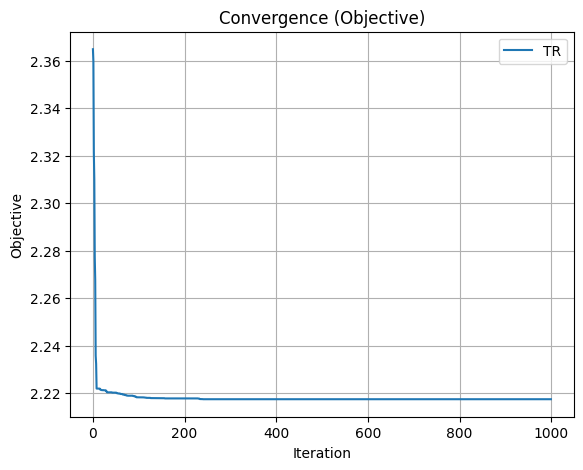

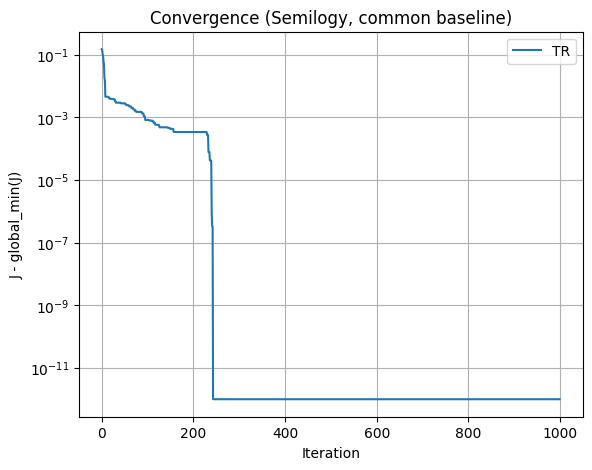

In [54]:
plot_convergence([res_tr])
plot_convergence_semilogy([res_tr])
show_all_animations([res_tr], prefer="js")

/var/folders/6n/_qkrlft93jn2pxhjxv34r4fw0000gn/T/ipykernel_56101/1321125445.py:141: DeprecationWarning: 'scipy.sparse.linalg.cg' keyword argument `tol` is deprecated in favor of `rtol` and will be removed in SciPy v1.14.0. Until then, if set, it will override `rtol`.
  Tvec, info = spla.cg(A, b, tol=tol, maxiter=maxiter, M=M, x0=x0)
/var/folders/6n/_qkrlft93jn2pxhjxv34r4fw0000gn/T/ipykernel_56101/1321125445.py:265: DeprecationWarning: 'scipy.sparse.linalg.cg' keyword argument `tol` is deprecated in favor of `rtol` and will be removed in SciPy v1.14.0. Until then, if set, it will override `rtol`.
  lam_vec, info = spla.cg(A, b, tol=self.pde.lin_tol, maxiter=self.pde.max_linits)


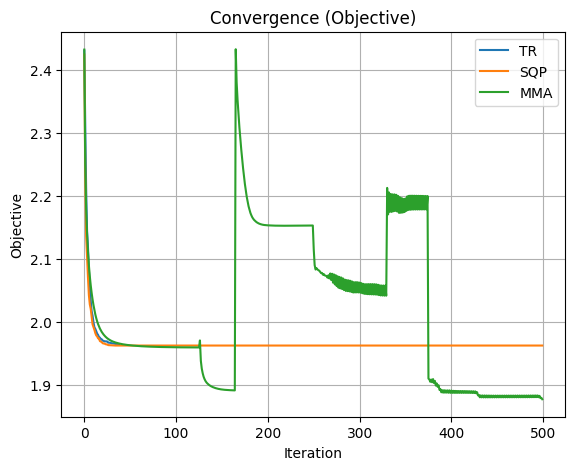

In [39]:
# You can cut iterations to test quickly by lowering CFG["max_iter"] or the grid size.
# For a fast smoke test, uncomment:
# CFG["nx"], CFG["ny"], CFG["max_iter"] = 64, 64, 80

results, ctx = run_all_solvers(CFG)
plot_convergence(results)
# plot_convergence_semilogy(results)
# show_all_animations(results, prefer="js")  # force no-ffmpeg path

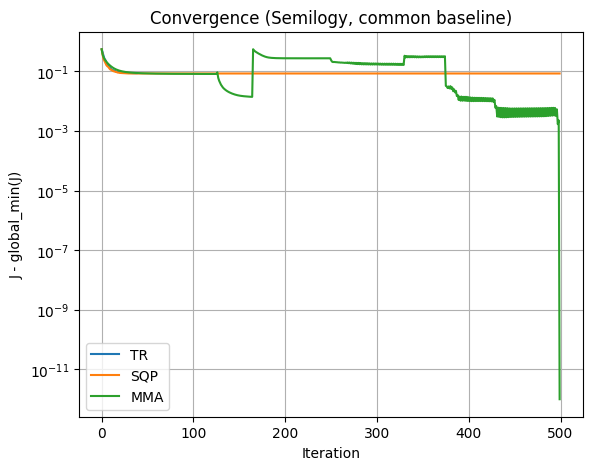

In [49]:
plot_convergence_semilogy(results)

In [50]:
show_all_animations(results, prefer="js")  # force no-ffmpeg path